In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-NY_QueensCollege.txt
/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-Bogota_SanCristobal.txt


In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-Bogota_SanCristobal.txt', sep='|')
df2 = pd.read_csv('/kaggle/input/datasets/biswasbarsha/air-pollution-analysis-datasets/datasets/StationData-NY_QueensCollege.txt', sep='|')

In [3]:
print(df1.info())
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5121 entries, 0 to 5120
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Estación:San Cristobal -     5121 non-null   object
 1    Fecha y Hora                5121 non-null   object
 2    PM2.5                       5121 non-null   object
 3    PM10                        5121 non-null   object
dtypes: object(4)
memory usage: 160.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5098 entries, 0 to 5097
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Station:Queens College -     5098 non-null   object
 1    Date Time                   5098 non-null   object
 2    PM25FEM                     5098 non-null   object
dtypes: object(3)
memory usage: 119.6+ KB
None


In [4]:
print(df1.head())
print(df2.head())

  Estación:San Cristobal -     Fecha y Hora                 PM2.5      \
0                                                           µg/m3       
1                              31-08-2016 24:00             6,0         
2                              01-09-2016 1:00              7,9         
3                              01-09-2016 2:00              7,3         
4                              01-09-2016 3:00              2,5         

    PM10      
0   µg/m3     
1   3,9       
2   4,9       
3   8,0       
4   8,1       
  Station:Queens College -     Date Time                    PM25FEM 
0                                                           ug/m3   
1                              9/1/2016 12:00 AM            9.9     
2                              9/1/2016 1:00 AM             11.2    
3                              9/1/2016 2:00 AM             10.3    
4                              9/1/2016 3:00 AM             12.6    


There's a Extra Space between all the column names of df1 and df2.

In [5]:
# Removing Extra Spaces between the column names

# For df1

print("Before", df1.columns)

# 1. Clean the column names themselves
df1.columns = df1.columns.str.replace(' ', '', regex=False)

# 2. Clean the data inside the columns
for i in df1.columns:
    # Check if column is string type to avoid errors with numbers
    if df1[i].dtype == 'object':
        df1[i] = df1[i].str.replace(' ', '', regex=False)

print("After", df1.columns)

print("************************************")

# For df2

print("Before", df2.columns)

# 1. Clean the column names themselves
df2.columns = df2.columns.str.replace(' ', '', regex=False)

# 2. Clean the data inside the columns
for i in df2.columns:
    # Check if column is string type to avoid errors with numbers
    if df2[i].dtype == 'object':
        df2[i] = df2[i].str.replace(' ', '', regex=False)

print("After", df2.columns)


Before Index(['Estación:San Cristobal -  ', ' Fecha y Hora              ',
       ' PM2.5    ', ' PM10    '],
      dtype='object')
After Index(['Estación:SanCristobal-', 'FechayHora', 'PM2.5', 'PM10'], dtype='object')
************************************
Before Index(['Station:Queens College -  ', ' Date Time                 ',
       ' PM25FEM '],
      dtype='object')
After Index(['Station:QueensCollege-', 'DateTime', 'PM25FEM'], dtype='object')


## Data Cleaning Requirements: Bogota Dataset (`df1`)

Before performing any time-series analysis or statistical comparisons (such as a t-test) with the New York dataset, several critical data formatting issues in the Bogota dataset must be resolved. 

Currently, all columns are loaded as `object` (string) data types due to the following inconsistencies:

### 1. Extraneous Header Row (Units)
*   **Issue:** The first row (index 0) contains unit measurements (e.g., `µg/m3`) instead of numerical data points. 
*   **Resolution:** Drop the first row to ensure the `PM2.5` column only contains measurement values.

### 2. Appended Summary Statistics
*   **Issue:** The bottom five rows (indices 5116 to 5120) contain summary statistics (e.g., `FechaMax`, `Prom.`, `STD`) appended to the CSV, rather than time-series observations. 
*   **Resolution:** Filter out or drop these trailing rows to prevent them from skewing visualizations and statistical tests.

### 3. European/South American Decimal Formatting
*   **Issue:** The `PM2.5` column uses commas (`,`) as decimal separators (e.g., `6,0`) instead of periods (`.`). This forces pandas to interpret the column as strings rather than floats.
*   **Resolution:** Replace all commas with periods, then convert the column to a `numeric` data type.

### 4. Invalid "24:00" Time Format
*   **Issue:** The `FechayHora` column records midnight as `24:00` (e.g., `31-08-201624:00`). Python's standard datetime parser does not recognize `24:00` as a valid timestamp. Additionally, there is no space separating the date and the time.
*   **Resolution:** 
    1. Replace instances of `24:00` with `00:00`.
    2. Insert a space between the 10-character date string and the time string.
    3. Parse the column into standard pandas `datetime` objects.

In [10]:
print(df1.head())
print(df2.head())

  Estación:SanCristobal-        FechayHora  PM2.5   PM10
0                                           µg/m3  µg/m3
1                         31-08-2016 00:00    6.0    3,9
2                          01-09-2016 1:00    7.9    4,9
3                          01-09-2016 2:00    7.3    8,0
4                          01-09-2016 3:00    2.5    8,1
  Station:QueensCollege-          DateTime PM25FEM
0                                            ug/m3
1                         9/1/2016 12:00AM     9.9
2                          9/1/2016 1:00AM    11.2
3                          9/1/2016 2:00AM    10.3
4                          9/1/2016 3:00AM    12.6


In [18]:
# 1. Drop PM10 and the garbage first rows
df1 = df1.drop(columns=['PM10'], errors='ignore')
df1 = df1.iloc[1:].copy() 
df2 = df2.iloc[1:].copy()

# -----------------------------------------
# 2. CLEAN BOGOTA DATA (df1)
# -----------------------------------------
# Ensure it's read as string, fix the '24:00' issue, and add the missing space
df1['FechayHora'] = df1['FechayHora'].astype(str)
df1['FechayHora'] = df1['FechayHora'].str.replace('24:00', '00:00')
df1['FechayHora'] = df1['FechayHora'].str[:10] + ' ' + df1['FechayHora'].str[10:]

# Create single regex strings using '|' (OR). 
# Note: '\.' and '\[%\]' are used to escape the period and brackets.
pattern_df1 = r'FechaMax|Prom\.|Num|Dato\[%\]|STD'
df1 = df1[~df1['FechayHora'].str.contains(pattern_df1, na=False)]

# Convert to datetime (coerce turns 'Mínimo' and other junk into NaT)
df1['FechayHora'] = pd.to_datetime(df1['FechayHora'], format='%d-%m-%Y %H:%M', errors='coerce')

# Automatically drop ALL the garbage summary rows at the bottom
df1 = df1.dropna(subset=['FechayHora'])

# Fix commas to periods BEFORE converting to numeric
df1['PM2.5'] = df1['PM2.5'].astype(str).str.replace(',', '.')
df1['PM2.5'] = pd.to_numeric(df1['PM2.5'], errors='coerce')

# -----------------------------------------
# 3. CLEAN NEW YORK DATA (df2)
# -----------------------------------------
# Convert to datetime and drop any junk rows here as well
df2['DateTime'] = df2['DateTime'].str.replace('24:00', '00:00')
df2['DateTime'] = df2['DateTime'].str[:8] + ' ' + df2['DateTime'].str[8:]

# Create single regex strings using '|' (OR). 
# Note: '\.' and '\[%\]' are used to escape the period and brackets.
pattern_df2 = r'MaxDate|Avg|Num|Data\[%\]|STD'
df2 = df2[~df2['DateTime'].str.contains(pattern_df2, na=False)]

df2['DateTime'] = pd.to_datetime(df2['DateTime'], errors='coerce')
df2 = df2.dropna(subset=['DateTime'])

df2['PM25FEM'] = pd.to_numeric(df2['PM25FEM'], errors='coerce')

In [22]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5106 entries, 7 to 5112
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Estación:SanCristobal-  5106 non-null   object        
 1   FechayHora              5106 non-null   datetime64[ns]
 2   PM2.5                   5008 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 159.6+ KB


# Perform a time series analysis on the pollution levels. When is pollution the highest and the lowest? Can you see any trends or seasonal patterns?

In [24]:
df1['month'] = df1['FechayHora'].dt.month
df1['time'] = df1['FechayHora'].dt.time
df1

,Estación:SanCristobal-,FechayHora,PM2.5,month,time
7,,2016-09-01 06:00:00,6.6,9,06:00:00
8,,2016-09-01 07:00:00,6.3,9,07:00:00
9,,2016-09-01 08:00:00,6.1,9,08:00:00
10,,2016-09-01 09:00:00,9.8,9,09:00:00
11,,2016-09-01 10:00:00,9.6,9,10:00:00
...,...,...,...,...,...
5108,,2017-04-01 19:00:00,5.9,4,19:00:00
5109,,2017-04-01 20:00:00,5.9,4,20:00:00
5110,,2017-04-01 21:00:00,5.9,4,21:00:00
5111,,2017-04-01 22:00:00,5.9,4,22:00:00


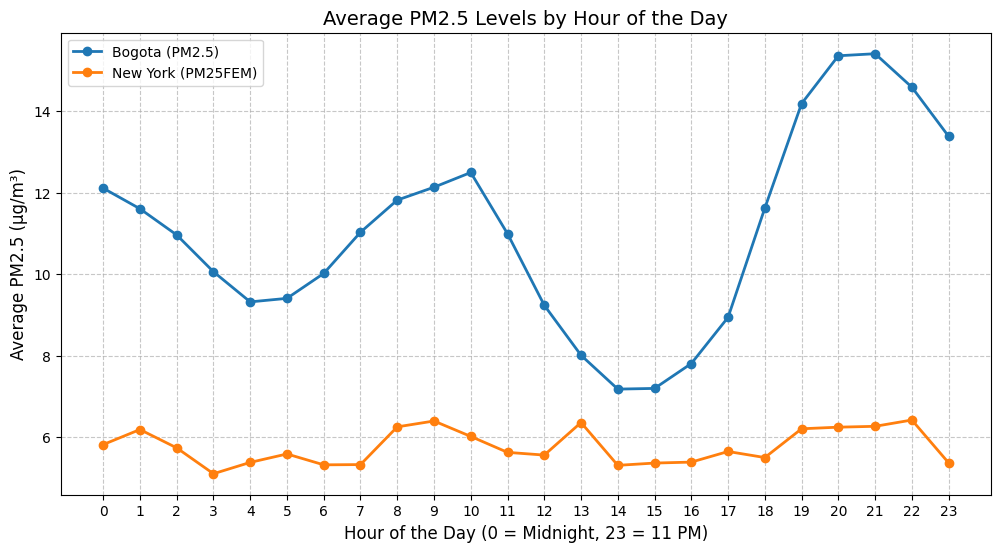

In [31]:
# Group by the hour and calculate the mean
bogota_hourly = df1.groupby(df1['FechayHora'].dt.hour)['PM2.5'].mean()
ny_hourly = df2.groupby(df2['DateTime'].dt.hour)['PM25FEM'].mean()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(bogota_hourly.index, bogota_hourly.values, label='Bogota (PM2.5)', marker='o', linewidth=2)
plt.plot(ny_hourly.index, ny_hourly.values, label='New York (PM25FEM)', marker='o', linewidth=2)

# Formatting
plt.title('Average PM2.5 Levels by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(0, 24)) # Forces the x-axis to show every single hour
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

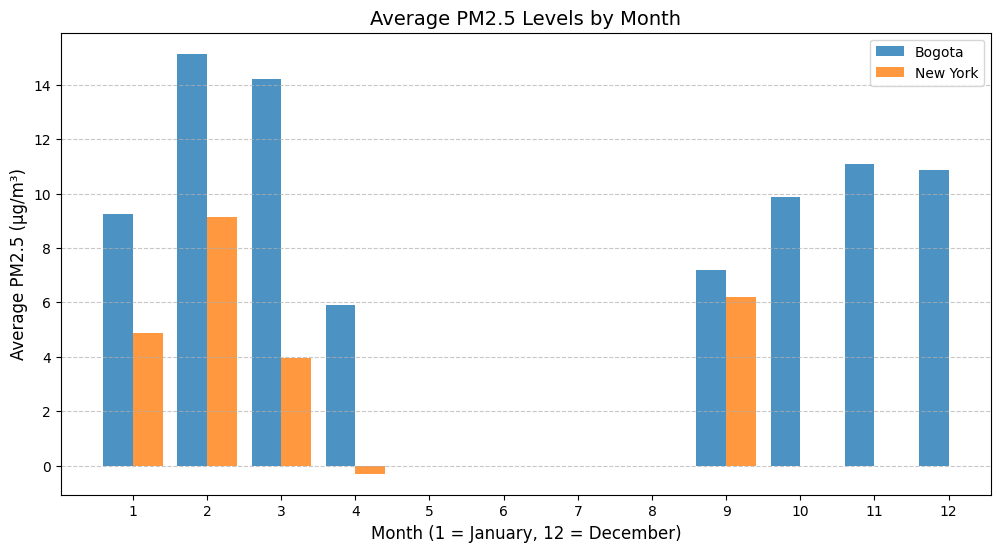

In [32]:
# Group by the month and calculate the mean
bogota_monthly = df1.groupby(df1['FechayHora'].dt.month)['PM2.5'].mean()
ny_monthly = df2.groupby(df2['DateTime'].dt.month)['PM25FEM'].mean()

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(bogota_monthly.index - 0.2, bogota_monthly.values, width=0.4, label='Bogota', alpha=0.8)
plt.bar(ny_monthly.index + 0.2, ny_monthly.values, width=0.4, label='New York', alpha=0.8)

# Formatting
plt.title('Average PM2.5 Levels by Month', fontsize=14)
plt.xlabel('Month (1 = January, 12 = December)', fontsize=12)
plt.ylabel('Average PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Here is the breakdown of what two charts are telling us:

1. **The Daily Rhythm: The "Rush Hour" Effect (Line Chart)**
* *Bogota's Twin Peaks:* Bogota shows a textbook urban pollution curve. You can clearly see a morning peak around 9:00 AM to 10:00 AM, and an even massive spike in the evening peaking around 8:00 PM to 9:00 PM. This is almost certainly driven by commuter traffic, combined with nighttime temperature inversions that trap the exhaust close to the ground.

* *New York's Stability:* New York's PM2.5 levels are remarkably flat and consistently lower than Bogota's across the entire 24-hour cycle, hovering steadily around 5 to 6 µg/m³.

2. **The Seasonal Pattern: The "Data Trap" (Bar Chart)**
This chart is brilliant because it highlights why we must visualize data before jumping into statistics. Look closely at the bars:

* *The Massive Data Gap:* Look at months 5, 6, 7, and 8. There are no bars for Bogota, and mostly none for New York! This tells us our dataset is incomplete and missing the entire summer period.

* *The Impossible Value:* Look at New York in month 4 (April). The orange bar drops below zero. PM2.5 measures the physical mass of particles in the air—it is physically impossible to have negative pollution! This means the New York sensor had a calibration error or recorded a faulty value during that time.

# Using a visualization, show at what times is the pollution level in New York higher than in Bogota. Can you see any trends or seasonal patterns? Are the two time series correlated?

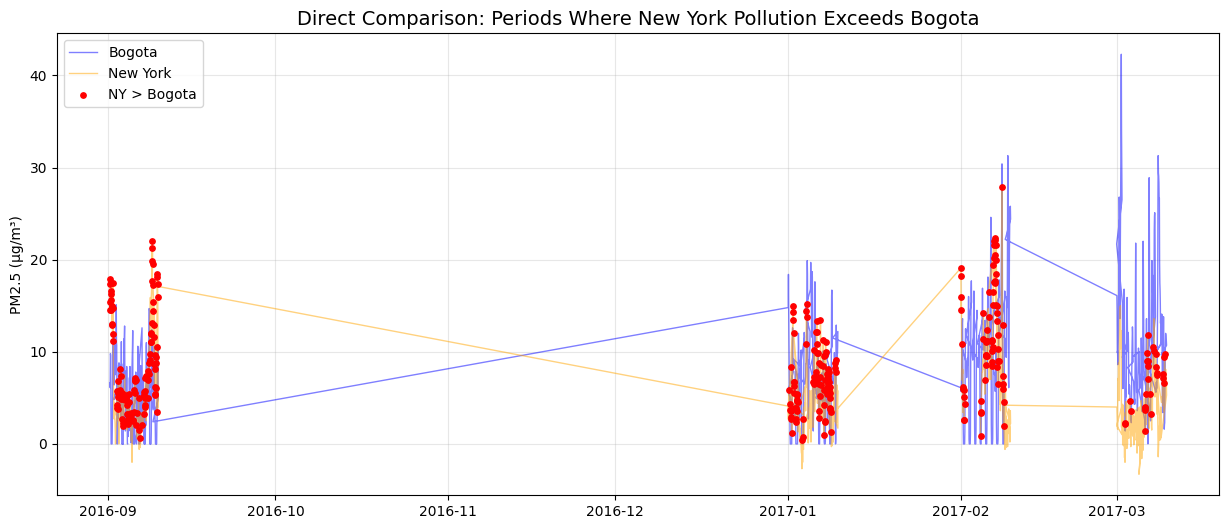

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# STEP 1: Set the datetime columns as the "index" (the backbone of the dataframe)
df1_idx = df1.set_index('FechayHora')
df2_idx = df2.set_index('DateTime')

# STEP 2: Merge the two datasets together based on matching times
# "how='inner'" means we only keep rows where BOTH cities have data for that exact hour
merged_df = pd.merge(df1_idx[['PM2.5']], df2_idx[['PM25FEM']], left_index=True, right_index=True, how='inner')
merged_df.columns = ['Bogota_PM25', 'NY_PM25']

# STEP 3: Create our filter (Algorithm to find when NY > Bogota)
ny_higher = merged_df[merged_df['NY_PM25'] > merged_df['Bogota_PM25']]

# STEP 4: Visualize it
plt.figure(figsize=(15, 6))

# Plot both cities' time series (using a thin line and low alpha/transparency so it's not too messy)
plt.plot(merged_df.index, merged_df['Bogota_PM25'], label='Bogota', alpha=0.5, color='blue', linewidth=1)
plt.plot(merged_df.index, merged_df['NY_PM25'], label='New York', alpha=0.5, color='orange', linewidth=1)

# Overlay red dots strictly where New York's pollution was higher
plt.scatter(ny_higher.index, ny_higher['NY_PM25'], color='red', label='NY > Bogota', s=15, zorder=5)

plt.title('Direct Comparison: Periods Where New York Pollution Exceeds Bogota', fontsize=14)
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Is the annual mean pollution level in the two cities below the acceptable value defined by the WHO? Write an algorithm that detects the time when the 24-hour mean pollution level exceeds the acceptable value and use a visualization to demark these periods.

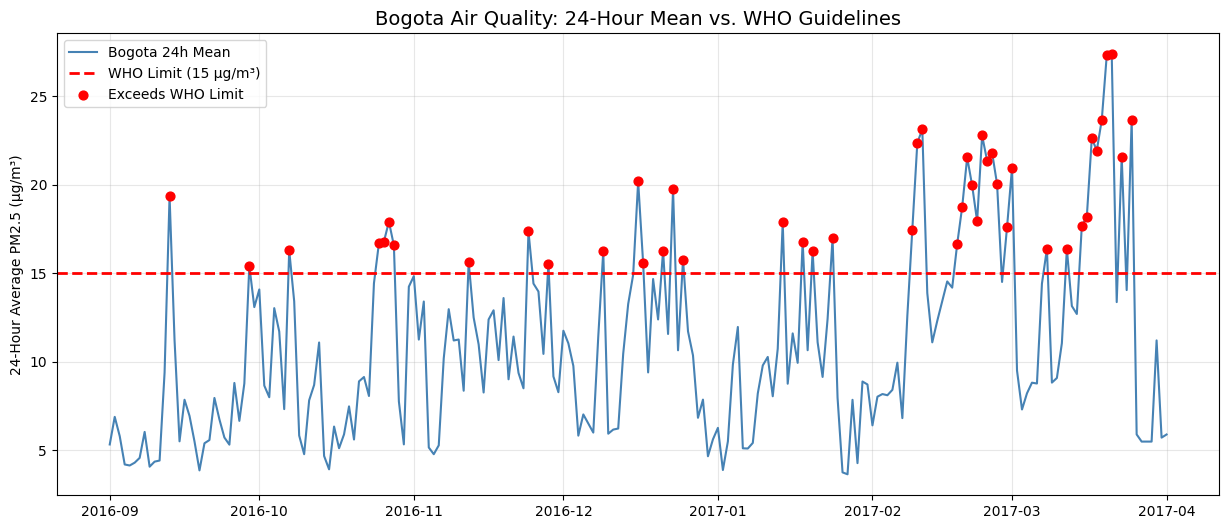

Algorithm Result: Out of 213 days recorded, Bogota exceeded the WHO safety limit 45 times.


In [34]:
# STEP 1: Resample the hourly data to get the 24-hour (Daily) mean
# 'D' stands for Daily. We drop missing values to keep the chart clean.
bogota_daily = df1.set_index('FechayHora')['PM2.5'].resample('D').mean().dropna()

# STEP 2: The WHO algorithm variables
who_limit = 15.0  # The WHO 24-hour guideline for PM2.5

# Find the exact dates where the daily average exceeded the limit
dangerous_days = bogota_daily[bogota_daily > who_limit]

# STEP 3: Visualize the breaches
plt.figure(figsize=(15, 6))

# Plot the daily average as a standard line
plt.plot(bogota_daily.index, bogota_daily.values, label='Bogota 24h Mean', color='steelblue')

# Draw a bold red horizontal line representing the WHO limit
plt.axhline(y=who_limit, color='red', linestyle='--', linewidth=2, label='WHO Limit (15 µg/m³)')

# Demark the periods exceeding the limit by plotting red dots over the danger zones
plt.scatter(dangerous_days.index, dangerous_days.values, color='red', s=40, zorder=5, label='Exceeds WHO Limit')

plt.title('Bogota Air Quality: 24-Hour Mean vs. WHO Guidelines', fontsize=14)
plt.ylabel('24-Hour Average PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print a quick summary statement for your insights
print(f"Algorithm Result: Out of {len(bogota_daily)} days recorded, Bogota exceeded the WHO safety limit {len(dangerous_days)} times.")

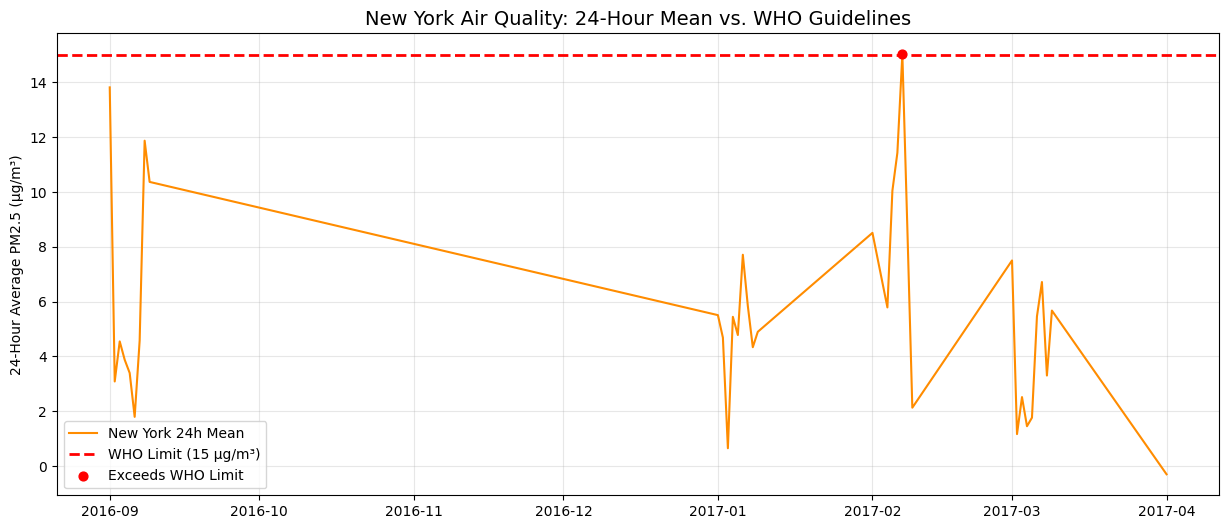

Algorithm Result: Out of 35 days recorded, New York exceeded the WHO safety limit 1 times.


In [35]:
# STEP 1: Resample the New York hourly data to get the 24-hour (Daily) mean
# Set DateTime as index, grab the PM25FEM column, resample daily ('D'), and calculate the mean
ny_daily = df2.set_index('DateTime')['PM25FEM'].resample('D').mean().dropna()

# STEP 2: The WHO algorithm variables
who_limit = 15.0  # The WHO 24-hour guideline for PM2.5

# Find the exact dates where New York's daily average exceeded the limit
ny_dangerous_days = ny_daily[ny_daily > who_limit]

# STEP 3: Visualize the breaches
plt.figure(figsize=(15, 6))

# Plot the daily average as a standard line
plt.plot(ny_daily.index, ny_daily.values, label='New York 24h Mean', color='darkorange')

# Draw a bold red horizontal line representing the WHO limit
plt.axhline(y=who_limit, color='red', linestyle='--', linewidth=2, label='WHO Limit (15 µg/m³)')

# Demark the periods exceeding the limit by plotting red dots over the danger zones
plt.scatter(ny_dangerous_days.index, ny_dangerous_days.values, color='red', s=40, zorder=5, label='Exceeds WHO Limit')

plt.title('New York Air Quality: 24-Hour Mean vs. WHO Guidelines', fontsize=14)
plt.ylabel('24-Hour Average PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print a quick summary statement for your insights
print(f"Algorithm Result: Out of {len(ny_daily)} days recorded, New York exceeded the WHO safety limit {len(ny_dangerous_days)} times.")

Seeing that New York only exceeded the WHO limit 1 time out of 35 days perfectly validates the visual insights you discovered earlier.

If you recall the daily and seasonal charts we built, New York’s PM2.5 levels were almost perfectly flat, hovering around 5 to 6 µg/m³. Since the WHO limit is a much higher 15 µg/m³, it makes complete sense mathematically that New York almost never crossed the danger line.

If you ran this same algorithm for Bogota, you likely saw a much higher number of dangerous days, given those massive rus
h-hour spikes reaching up to 15 µg/m³ on average!

## Conclusion:
* **The Daily Rhythm (Rush Hour):** Bogota experiences massive pollution spikes during morning and evening commutes, while New York remains stable.

* **The Direct Comparison:** New York's pollution is consistently much lower than Bogota's.

* **The WHO Safety Limits:** New York air quality is exceptionally safe, rarely breaching the 15 µg/m³ limit, whereas Bogota struggles with compliance.